Import libraries to project

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table

Import data set

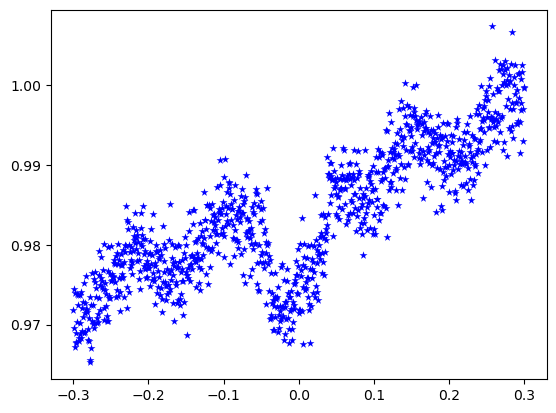

In [2]:
plcData = Table.read("Planet_Lightcurve.fits",format = "fits")
time = np.asarray(plcData["time [days]"])
flux = np.asarray(plcData["flux"])
plt.scatter(time,flux,c='b',marker='*',linewidth=0.0025)

In [3]:
def modelLine(x,m,b):
    '''
    Model a line using the given parameters
        The function of a line is equal to f(x) = mx + b
        
    Input
        x: 1d array of input values
        m: slope of the line
        b: y intercept of the line
    Output
        y: 1d array with the same size as x, each value is equal to f(x)
    '''
    y = x * m
    y += b
    
    return y

def modelSine(x,amp,freq,shift):
    '''
    Model a sinusoid using the given parameters
        The function of a sinusoidal equation is equal to g(x) = amp * sin(freq * x + shift)
        
    Input
        x: 1d array of input values
        amp: amplitude of the sinusoid (how tall it is)
        freq: frequency of the sinusoid (how fast it repeats)
        shift: angle shift of the sinusoid (where it starts)
            (sine and cosine are actually the same function, however cosine is simply shifted forwards 90 degrees
            our sinusoid may not start at the g(0) = 0. For example, the sinusoid may start a third of the way through its oscillation)
    Output
        y: 1d array with the same size as x, each value is equal to g(x)
    '''
    #create the values to input into np.sin(), seperated visually for aesthetics and ease of comprehension
    inputValues = x * freq
    inputValues += shift
    y = np.sin(inputValues)
    y *= amp

    return y
def modelCombination(x,m,b,a,f,s):
    '''
    Model the addition of a sinusoid and a line
        The function of this combination is equal to h(x) = f(x) + g(x)
            Where f(x) and g(x) are the line and sinusoid respectively
        
    Input
        x: 1d array of input values
        m: slope of the line
        b: y intercept of the line
        a: amplitude of the sinusoid (how tall it is)
        f: frequency of the sinusoid (how fast it repeats)
        s: angle shift of the sinusoid (where it starts)
            (sine and cosine are actually the same function, however cosine is simply shifted forwards 90 degrees
            our sinusoid may not start at the g(0) = 0. For example, the sinusoid may start a third of the way through its oscillation)
    Output
        y: 1d array with the same size as x, each value is equal to g(x)
    '''
    #model our line
    line = modelLine(x,m,b)
    #model our sinusoid
    sine = modelSine(x,a,f,s)
    y = line + sine
    return y

In [4]:
def calculateS(yData, yModel):
    '''
    Calculate sigmas for the data
    
    Input
        yData: 1d array_like, data points to fit model into
        yModel: 1d array_like with same length as yData. Model to compare against data

    Output
        S: sum of the residuals squared between models and data
    '''

    #calculate the residuals
    residuals = yData - yModel

    S = np.sum(residuals**2)
    return S

In [5]:
def findFit(xData,yData,p0,model,nSteps = 500, jumpSig=0.01):
    '''
    Find the best fit for h(x) = f(x) + g(x)
        wherein f(x) = m * x + b
        and g(x) = amp * sin(freq * x + shift)
            See modelline(), modelsine(), and modelCombination for details on these functions
    
    Input
        xData: 1d array-like, giving x-coordinates of dataset to be fitted
        yData: 1d array-like, giving y-coordinates of dataset to be fitted
        p0: array-like giving initial guess for the model
            wherein our guess is for all coefficients, [m,b,amp,freq,shift]
        model: model function to use
        nSteps (optional): int, number of steps for random walker. Default is 500
        jumpSig (optional): array-like, standard deviation to be used in random jump

    Output
        walk: nd-array of shape (nsteps+1,len(p0)) random walk where each step
            improves the fit from the last one
            
            walk[:,0] is all of the values of m
            walk[:,1] is all of the values of b
            walk[:,2] is all of the values of amp
            walk[:,3] is all of the values of freq
            walk[:,4] is all of the values of shift
            
        Ss: 1d-array of len(nSteps) + 1, gives the value of S for each step
    '''
    #create walk array filled with zeroes
        #length is nSteps+1 because the first value is equal to our initial guess
    walk = np.zeros(shape=(nSteps + 1, len(p0)))

    #set the first position equal to our initial guess
    walk[0,:] = p0

    #create empty array
    Ss = []

    #first value of S is the one from the initial guess
    Ss.append(calculateS(yData,model(xData,*p0)))

    i = 0
    while (len(Ss) < nSteps+1):
        #grab latest position
        previousPosition = walk[i,:]

        #making the jump be a gaussian with standard deviation sigma and mean of 0
        #the size should be len(p0) such that the variable jump can be applied to each coordinate at once
        jump = np.random.normal(scale = jumpSig, size = len(p0))

        #applying the jump to previousPosition, getting the new position of the walker
        newPosition = previousPosition + jump

        #calculate S after jump
        sJump =  calculateS(yData,model(xData,*newPosition))

        #if this S is smaller than the previous one, save it
        if sJump <= Ss[i]:
            #save the new value of S in the list, increasing the len of S by another step
            Ss.append(sJump)
            
            #saving the new position into our return array
            walk[i+1,:] = newPosition

            #iterate
            i+=1
        elif np.random.random() < np.exp(Ss[i] - sJump):
            #save the new value of S in the list, increasing the len of S by another step
            Ss.append(sJump)
            
            #saving the new position into our return array
            walk[i+1,:] = newPosition

            #iterate
            i+=1
        else:
            continue
    
    #once the loop is over, return the walk to the user
    #Since we originally defined S as a python list, transform it to a numpy array
    return walk, np.asarray(Ss)

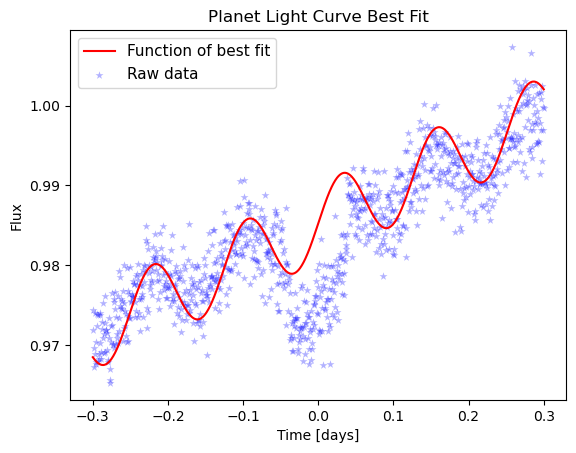

In [38]:
#Obtained through eyeballing graph
initialGuess = [0.0456666,0.985,0.005,50,0]

#low sigma value and high step count
    #as different values vary in sensitivity
    #E.g. Frequency is around 50 but amplitude is around 0.005
        #Too large of sigma and the best fit won't be able to get a good value for the tiny values
        #Too few steps with a low sigma and the best fit won't have time to accommodate for larger values
walkExample, sExample = findFit(time,flux, initialGuess, modelCombination,nSteps=5000,jumpSig=0.000005)

#Grab the most recent (and best) guess
values = walkExample[-1,:]

#Plot the best fit and data together
plt.plot(time,modelCombination(time,*values),c='r',zorder=2,label="Function of best fit")
plt.scatter(time,flux,c='b',marker='*',linewidth=0.0025,alpha=0.3,zorder=1,label="Raw data")
plt.xlabel("Time [days]")
plt.ylabel("Flux")
plt.legend(fontsize = 11)
plt.title("Planet Light Curve Best Fit")
plt.savefig("PlanetLightCurve.pdf",format="pdf")